In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../dataset/superstore_sales.csv")

# Show first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1.0,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2.0,CA-2017-152156,08-11-2017,11-11-2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3.0,CA-2017-138688,12-06-2017,16-06-2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4.0,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5.0,US-2016-108966,11-10-2016,18-10-2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
#show dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9803 entries, 0 to 9802
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   float64
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9801 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(3), str(

In [3]:
#col names displayed
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [4]:
#only important columns
df[['Order Date', 'Sales', 'Category', 'Sub-Category']].head()

,Order Date,Sales,Category,Sub-Category
0,08-11-2017,261.9600,Furniture,Bookcases
1,08-11-2017,731.9400,Furniture,Chairs
2,12-06-2017,14.6200,Office Supplies,Labels
3,11-10-2016,957.5775,Furniture,Tables
4,11-10-2016,22.3680,Office Supplies,Storage


In [5]:
#order date to date-time format
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst = True)

#data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9803 entries, 0 to 9802
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   float64       
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   str           
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9801 non-null   str           
 15  Sub-Category   9800 non-null   s

In [6]:
#extracting yr from order date
df['Year'] = df['Order Date'].dt.year

#tot sales by year
yearly_sales = df.groupby('Year')['Sales'].sum()

print(yearly_sales)

Year
2015.0    479856.2081
2016.0    459436.0054
2017.0    600192.5500
2018.0    722052.0192
Name: Sales, dtype: float64


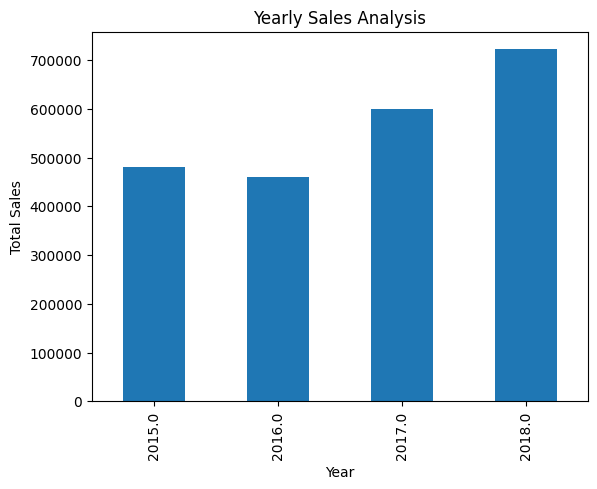

In [7]:
import matplotlib.pyplot as plt

#yearly sales graph
yearly_sales.plot(kind = 'bar')

#title and labels
plt.title('Yearly Sales Analysis')
plt.xlabel('Year')
plt.ylabel('Total Sales')

#show graph
plt.show()

In [8]:
#monthly sales analysis

#extracting months from order date
df['Month'] = df['Order Date'].dt.month

#sales by month
monthly_sales = df.groupby('Month')['Sales'].sum()

print(monthly_sales)

Month
1.0      94291.6296
2.0      59371.1154
3.0     197573.5872
4.0     136283.0006
5.0     154086.7237
6.0     145837.5233
7.0     145535.6890
8.0     157315.9270
9.0     300103.4117
10.0    199496.2947
11.0    350161.7110
12.0    321480.1695
Name: Sales, dtype: float64


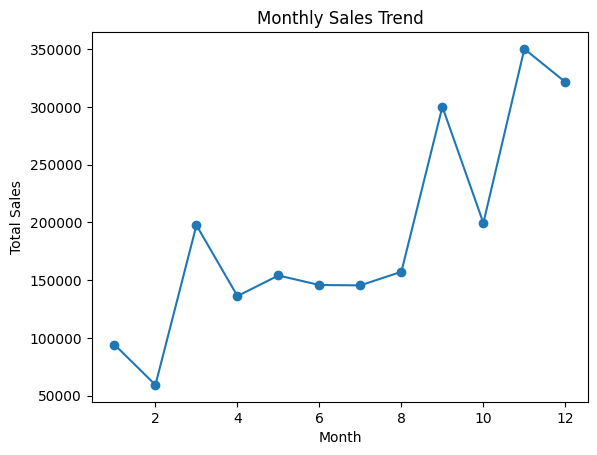

In [9]:
#line graph for monthly sales trend
monthly_sales.plot(kind = 'line', marker = 'o')

#titles and labels
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

#graph
plt.show()

In [10]:
#category wise sales analysis

category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
*                       0.0000
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


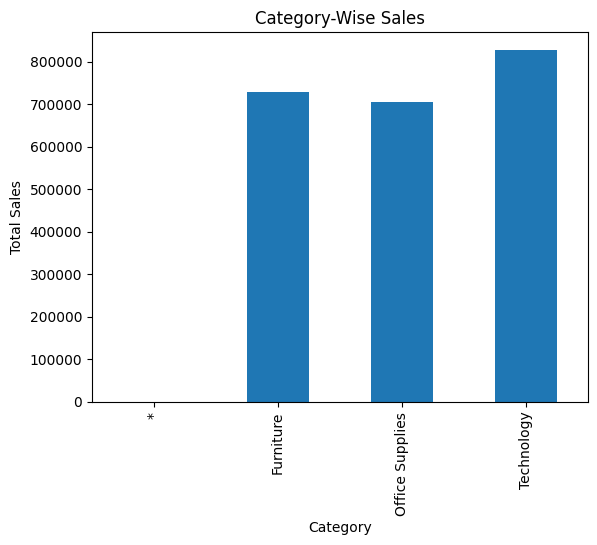

In [11]:
#graph of category wise sales
category_sales.plot(kind = 'bar')

#titles and labels
plt.title('Category-Wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')

#graph print
plt.show()

In [12]:
#Day 2 begins

#Time series preparation

#Sorting by ORDER DATE
df = df.sort_values(by= 'Order Date')

#First 5 rows after sorting
df[['Order Date', 'Sales']].head()

,Order Date,Sales
7980,2015-01-03,16.448
741,2015-01-04,3.540
740,2015-01-04,272.736
739,2015-01-04,11.784
1759,2015-01-05,19.536


In [13]:
# monthly aggregation

# Year-Month Col
df['YearMonth'] = df['Order Date'].dt.to_period('M')

# Sales by YearMonth
monthly_data = df.groupby('YearMonth')['Sales'].sum()

# Displaying first 10 rows
print(monthly_data.head(12))

YearMonth
2015-01    14205.7070
2015-02     4519.8920
2015-03    55205.7970
2015-04    27906.8550
2015-05    23644.3030
2015-06    34322.9356
2015-07    33781.5430
2015-08    27117.5365
2015-09    81623.5268
2015-10    31453.3930
2015-11    77907.6607
2015-12    68167.0585
Freq: M, Name: Sales, dtype: float64


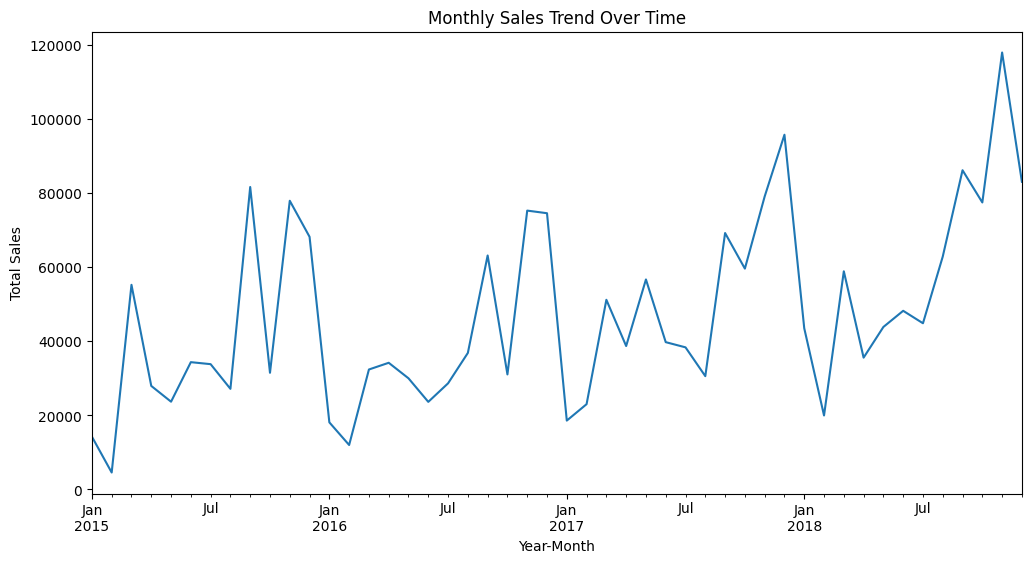

In [14]:
#time series visualisation - monthly sales trend graph
monthly_data.plot(figsize = (12,6))

plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales')

plt.show()

In [15]:
# monthly data to dataframe
monthly_data = monthly_data.reset_index() #grouped idx back to normal cols

# renaming cols
monthly_data.columns = ['YearMonth', 'Sales']

# first 5 rows
monthly_data.head()

,YearMonth,Sales
0,2015-01,14205.707
1,2015-02,4519.892
2,2015-03,55205.797
3,2015-04,27906.855
4,2015-05,23644.303


In [16]:
#time idx creation
monthly_data['TimeIndex'] = range(1, len(monthly_data) + 1)

#first 10 rows
monthly_data.head(10)

,YearMonth,Sales,TimeIndex
0,2015-01,14205.7070,1
1,2015-02,4519.8920,2
2,2015-03,55205.7970,3
3,2015-04,27906.8550,4
4,2015-05,23644.3030,5
5,2015-06,34322.9356,6
6,2015-07,33781.5430,7
7,2015-08,27117.5365,8
8,2015-09,81623.5268,9
9,2015-10,31453.3930,10


In [17]:
from sklearn.linear_model import LinearRegression

# Features & Target (I/P & O/P)
X = monthly_data[['TimeIndex']]
y = monthly_data['Sales']

# Model creation
model = LinearRegression()

# Model Training
model.fit(X, y)

print("Model Trained successfully!")

Model Trained successfully!


In [18]:
# generating predictions
monthly_data['PredictedSales'] = model.predict(X)

monthly_data.head(10)

,YearMonth,Sales,TimeIndex,PredictedSales
0,2015-01,14205.7070,1,26240.013137
1,2015-02,4519.8920,2,27128.325329
2,2015-03,55205.7970,3,28016.637521
3,2015-04,27906.8550,4,28904.949712
4,2015-05,23644.3030,5,29793.261904
5,2015-06,34322.9356,6,30681.574095
6,2015-07,33781.5430,7,31569.886287
7,2015-08,27117.5365,8,32458.198478
8,2015-09,81623.5268,9,33346.510670
9,2015-10,31453.3930,10,34234.822862


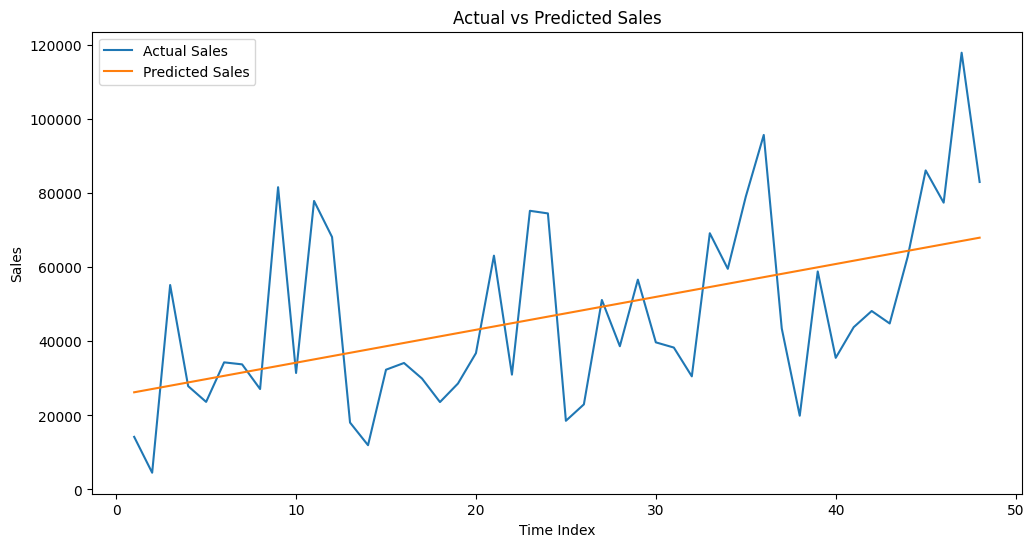

In [19]:
# actual vs predicted sales plotting
plt.figure(figsize = (12, 6))

# actual sales
plt.plot(monthly_data['TimeIndex'], monthly_data['Sales'], label = 'Actual Sales')

# predicted sales
plt.plot(monthly_data['TimeIndex'], monthly_data['PredictedSales'], label = 'Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Time Index')
plt.ylabel('Sales')

plt.legend()
plt.show()

In [20]:
# MAE - Mean Absolute Error
from sklearn.metrics import mean_absolute_error

#calculation
mae = mean_absolute_error(monthly_data['Sales'], monthly_data['PredictedSales'])
print("MAE = ", mae)

MAE =  17400.980583528202


In [21]:
# Day 3 - 27 May 2026

# Data splitting into TRAINING & TESTING sets

train_size = int(len(monthly_data) * 0.8)

train_data = monthly_data[:train_size]
test_data = monthly_data[train_size:]

print("Training Data Size: ", len(train_data))
print("Test Data Size: ", len(test_data))

Training Data Size:  38
Test Data Size:  10


In [22]:
# Training features and target
X_train = train_data[['TimeIndex']]
y_train = train_data['Sales']

# Testing features and target
X_test = test_data[['TimeIndex']]
y_test = test_data['Sales']

print("Training and testing features created successfully!")

Training and testing features created successfully!


In [23]:
# Proper model trianing with training data
from sklearn.linear_model import LinearRegression

# Creating model
model = LinearRegression()

# Train only on training data
model.fit(X_train, y_train)

print("Model trained on training data successfully!")

Model trained on training data successfully!


In [24]:
# Testing data prediction
test_prediction = model.predict(X_test)
print(test_prediction)

[55563.60123585 56249.8827636  56936.16429134 57622.44581909
 58308.72734684 58995.00887459 59681.29040234 60367.57193009
 61053.85345784 61740.13498559]


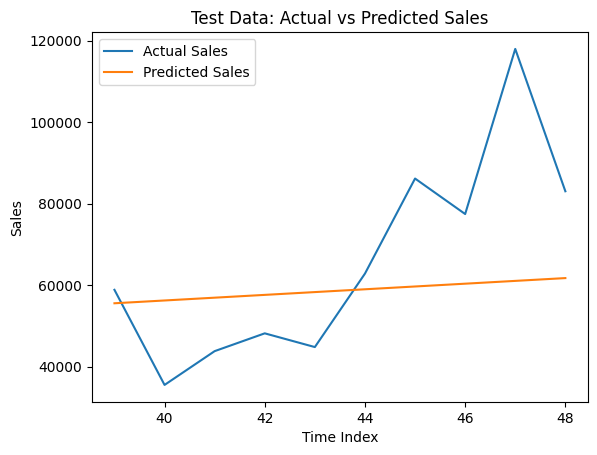

In [25]:
# Actual vs Predicted Test Data

# Graph
plt.Figure(figsize = (12,6))

# Actual Sales
plt.plot(test_data['TimeIndex'], y_test, label = 'Actual Sales')

# Predicted Sales
plt.plot(test_data['TimeIndex'], test_prediction, label = 'Predicted Sales')

plt.title('Test Data: Actual vs Predicted Sales')
plt.xlabel('Time Index')
plt.ylabel('Sales')

plt.legend()
plt.show()

In [26]:
#future predictions

# future time idxs
future_time = pd.DataFrame({
    'TimeIndex': range(
        monthly_data['TimeIndex'].max() + 1, 
        monthly_data['TimeIndex'].max() + 13, 
    )
})

# Future sales prediction
future_prediction = model.predict(future_time)
print(future_prediction)

[62426.41651334 63112.69804109 63798.97956884 64485.26109659
 65171.54262434 65857.82415208 66544.10567983 67230.38720758
 67916.66873533 68602.95026308 69289.23179083 69975.51331858]


In [27]:
# DAY 4 - 28 MAY 2026

# RESIDUAL ANALYSIS

# calculating and printing residuals
residuals = y_test - test_prediction
print(residuals)

38     3299.811564
39   -20707.972664
40   -13110.182091
41    -9431.718119
42   -13483.623347
43     3842.839125
44    26471.597598
45    17080.559270
46    56884.301542
47    21290.253814
Name: Sales, dtype: float64


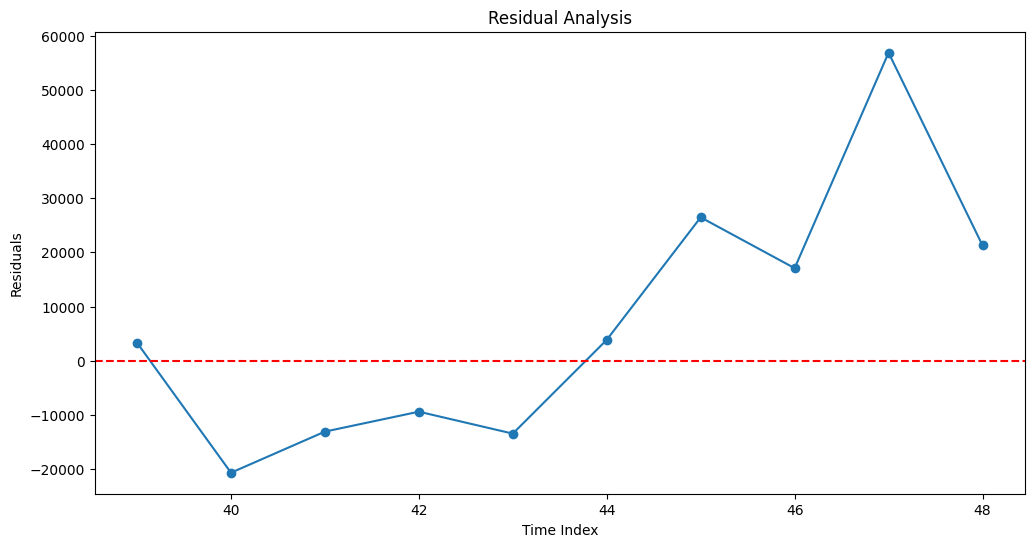

In [28]:
# Residual Analysis Graph
plt.figure(figsize = (12,6))
plt.plot(test_data['TimeIndex'], residuals, marker = 'o')

# Horizontal 0 line
plt.axhline(y = 0, color = 'red', linestyle = '--')

# Labels
plt.title('Residual Analysis')
plt.xlabel('Time Index')
plt.ylabel('Residuals')

# Print graph
plt.show()

In [29]:
# R² score of model

from sklearn.metrics import r2_score
r2 = r2_score(y_test, test_prediction)
print("R² score = ", r2)

R² score =  0.03323365449775528


In [30]:
print("Possible Improvements:")
print("- Use advanced forecasting models")
print("- Include seasonal features")
print("- Use more historical data")
print("- Apply non-linear machine learning models")
print("- Include external business factors")

Possible Improvements:
- Use advanced forecasting models
- Include seasonal features
- Use more historical data
- Apply non-linear machine learning models
- Include external business factors


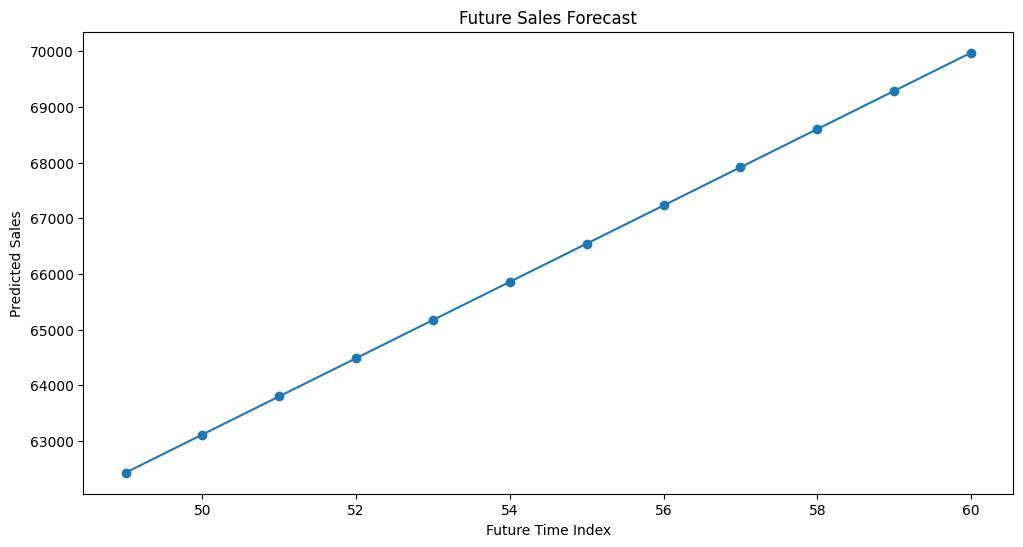

In [31]:
# DAY 5 - 28 MAY

# FUTURE FORECASTING GRAPH
plt.figure(figsize = (12,6))

# future prediction line
plt.plot(future_time['TimeIndex'], future_prediction, marker = 'o')

plt.title('Future Sales Forecast')
plt.xlabel('Future Time Index')
plt.ylabel('Predicted Sales')

plt.show()

In [32]:
# Moving Avg
monthly_data['MovingAvg'] = monthly_data['Sales'].rolling(window = 3).mean()

monthly_data.head(10)

,YearMonth,Sales,TimeIndex,PredictedSales,MovingAvg
0,2015-01,14205.7070,1,26240.013137,NaN
1,2015-02,4519.8920,2,27128.325329,NaN
2,2015-03,55205.7970,3,28016.637521,24643.798667
3,2015-04,27906.8550,4,28904.949712,29210.848000
4,2015-05,23644.3030,5,29793.261904,35585.651667
5,2015-06,34322.9356,6,30681.574095,28624.697867
6,2015-07,33781.5430,7,31569.886287,30582.927200
7,2015-08,27117.5365,8,32458.198478,31740.671700
8,2015-09,81623.5268,9,33346.510670,47507.535433
9,2015-10,31453.3930,10,34234.822862,46731.485433


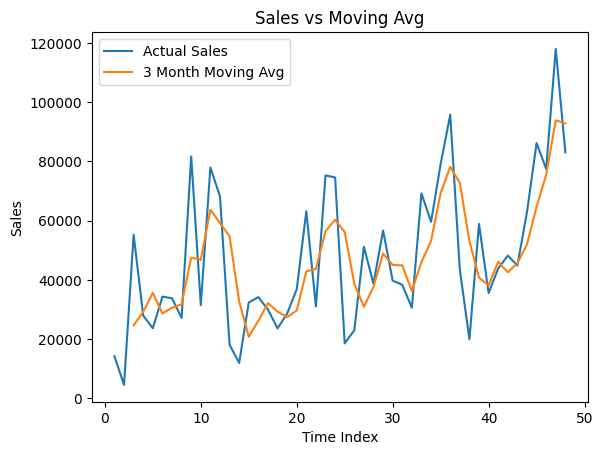

In [33]:
# Actual Sales vs Moving Avg Graph
plt.Figure(figsize = (12,6))

# Actual Sales
plt.plot(monthly_data['TimeIndex'],
         monthly_data['Sales'],
         label='Actual Sales')

# Moving Avg
plt.plot(monthly_data['TimeIndex'],
         monthly_data['MovingAvg'],
         label = '3 Month Moving Avg')

# Labels
plt.title('Sales vs Moving Avg')
plt.xlabel('Time Index')
plt.ylabel('Sales')

plt.legend()
plt.show()

In [34]:
# Std Deviatiom

actual_std = monthly_data['Sales'].std()
moving_avg_std = monthly_data['MovingAvg'].std()

print("Actual Sales Std Deviation = ", actual_std)
print("Moving Avg Std Deviation = ", moving_avg_std)

Actual Sales Std Deviation =  24978.68730455254
Moving Avg Std Deviation =  17335.27360533585


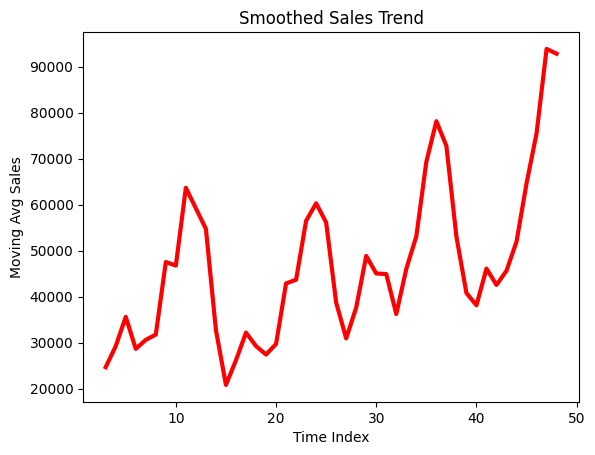

In [35]:
# Moving Avg Trend Graph

plt.Figure(figsize = (12,6))

plt.plot(monthly_data['TimeIndex'],
         monthly_data['MovingAvg'],
         color = 'red',
         linewidth = 3)

plt.title('Smoothed Sales Trend')
plt.xlabel('Time Index')
plt.ylabel('Moving Avg Sales')

plt.show()

In [36]:
# monthly % change calculation
monthly_data['MonthlyGrowth'] = monthly_data['Sales'].pct_change() * 100

monthly_data[['YearMonth',
              'Sales',
              'MonthlyGrowth']].head(10)

,YearMonth,Sales,MonthlyGrowth
0,2015-01,14205.7070,NaN
1,2015-02,4519.8920,-68.182562
2,2015-03,55205.7970,1121.396374
3,2015-04,27906.8550,-49.449412
4,2015-05,23644.3030,-15.274211
5,2015-06,34322.9356,45.163660
6,2015-07,33781.5430,-1.577349
7,2015-08,27117.5365,-19.726768
8,2015-09,81623.5268,200.999048
9,2015-10,31453.3930,-61.465286


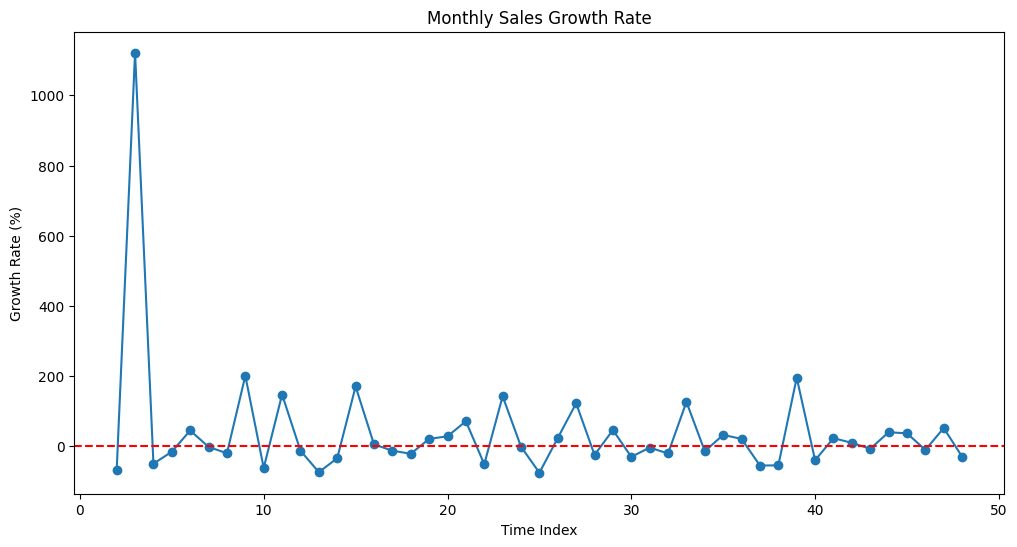

In [37]:
# Monthly growth rate Graph

plt.figure(figsize=(12,6))

plt.plot(monthly_data['TimeIndex'],
         monthly_data['MonthlyGrowth'],
         marker='o')

# Horizontal zero line
plt.axhline(y=0,
            color='red',
            linestyle='--')

# Labels and title
plt.title('Monthly Sales Growth Rate')
plt.xlabel('Time Index')
plt.ylabel('Growth Rate (%)')

# Show graph
plt.show()

In [38]:
# DAY 6 - 30 May

#Calculation of Correlation Matrix
correlation_matrix = monthly_data[
    ['Sales',
     'TimeIndex',
     'MovingAvg',
     'MonthlyGrowth']
].corr()

print(correlation_matrix)

                  Sales  TimeIndex  MovingAvg  MonthlyGrowth
Sales          1.000000   0.497879   0.720269       0.237270
TimeIndex      0.497879   1.000000   0.591501      -0.206953
MovingAvg      0.720269   0.591501   1.000000      -0.201099
MonthlyGrowth  0.237270  -0.206953  -0.201099       1.000000


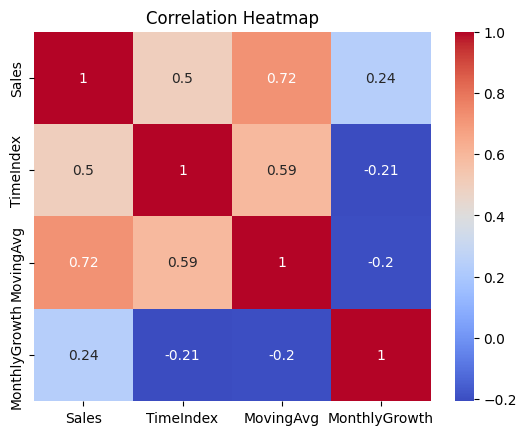

In [39]:
# correlation heatmap

import seaborn as sns
plt.Figure(figsize = (8,6))

sns.heatmap(correlation_matrix,
            annot = True,
            cmap = 'coolwarm')

plt.title('Correlation Heatmap')
plt.show()

In [40]:
# Category wise Total Sales
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
*                       0.0000
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


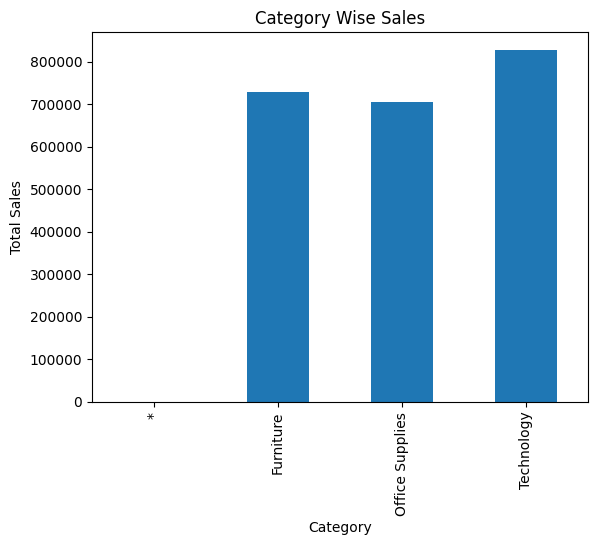

In [41]:
# Category wise sales graph

plt.Figure(figsize = (8,6))
category_sales.plot(kind = 'bar')

plt.title('Category Wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')

plt.show()

In [42]:
# sub-category sales analysis
subcat_sales = df.groupby('Sub-Category')['Sales'].sum()

# descending sort
subcat_sales = subcat_sales.sort_values(ascending = False)

print(subcat_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


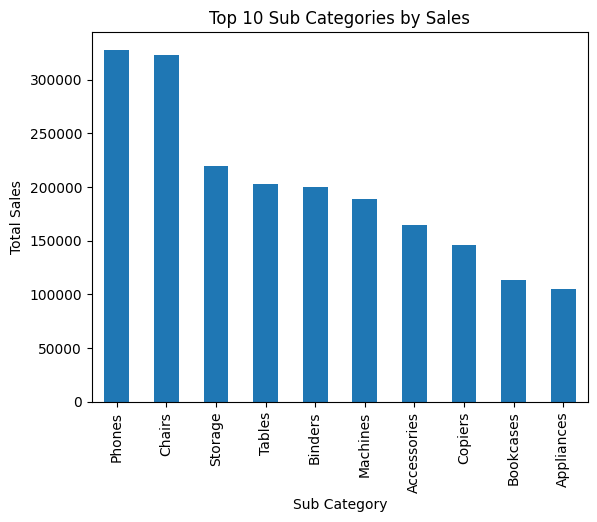

In [43]:
# Top 10 Sub Category Sales Graph

plt.Figure(figsize = (12,6))
subcat_sales.head(10).plot(kind = 'bar')

plt.title('Top 10 Sub Categories by Sales')
plt.xlabel('Sub Category')
plt.ylabel('Total Sales')

plt.show()

In [44]:
# Reload original dataset

raw_df = pd.read_csv('../dataset/superstore_sales.csv')

# Display columns
print(raw_df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')


In [45]:
# Geographic Segmentation

# Region-wise sales

region_sales = raw_df.groupby('Region')['Sales'].sum()

# Sort descending
region_sales = region_sales.sort_values(ascending=False)

# Display results
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


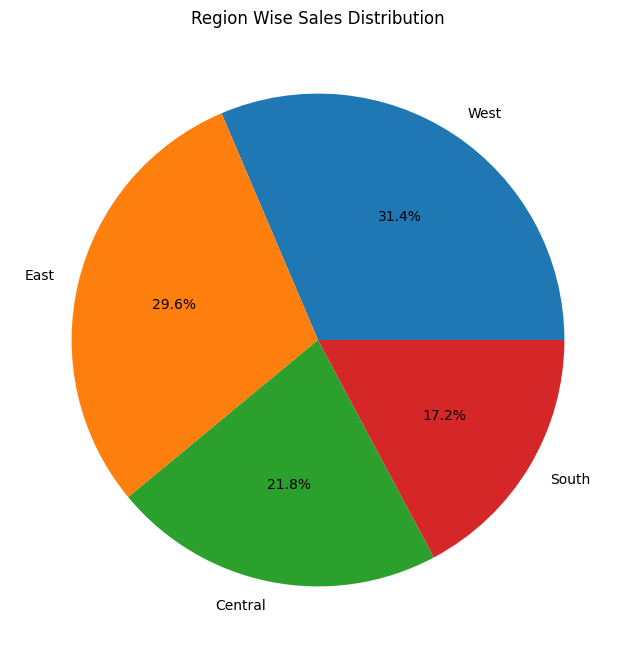

In [46]:
# Region-wise sales pie chart
plt.figure(figsize=(8,8))

region_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

# Remove extra label
plt.ylabel('')

# Title
plt.title('Region Wise Sales Distribution')

# Show chart
plt.show()

In [47]:
# Segment-wise sales

seg_sales = raw_df.groupby('Segment')['Sales'].sum()

# Sort descending
seg_sales = seg_sales.sort_values(ascending=False)

# Display results
print(seg_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


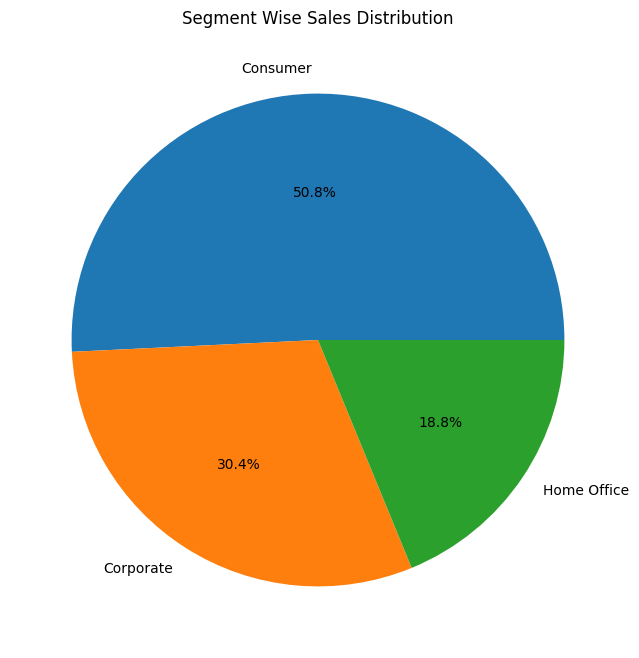

In [48]:
# Segment-wise sales pie chart

plt.figure(figsize=(8,8))
seg_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title('Segment Wise Sales Distribution')
plt.show()

In [49]:
### Day 7 - 1st June

## Quarter wise sales analysis

#Quarter column
raw_df['Qtr'] = pd.to_datetime(
    raw_df['Order Date'],
    dayfirst = True
).dt.quarter

# Quarter wise sales
qtr_sales = raw_df.groupby('Qtr')['Sales'].sum()
print(qtr_sales)

Qtr
1.0    351236.3322
2.0    436207.2476
3.0    602955.0277
4.0    871138.1752
Name: Sales, dtype: float64


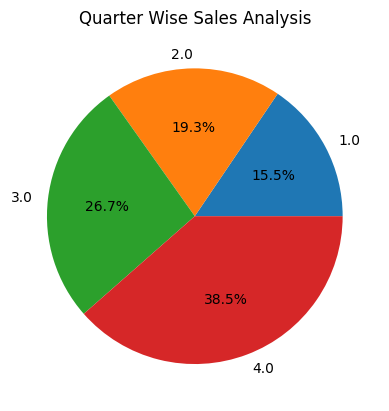

In [50]:
#Qtrly Sales Pie Chart
plt.Figure(figsize = (8,8))

qtr_sales.plot(
    kind = 'pie',
    autopct = '%1.1f%%',
)

plt.ylabel('')

plt.title('Quarter Wise Sales Analysis')
plt.show()

In [51]:
# Year column in raw_df

raw_df['Year'] = pd.to_datetime(
    raw_df['Order Date'],
    dayfirst=True
).dt.year

# Check first few rows
raw_df[['Order Date', 'Year']].head()

,Order Date,Year
0,08-11-2017,2017.0
1,08-11-2017,2017.0
2,12-06-2017,2017.0
3,11-10-2016,2016.0
4,11-10-2016,2016.0


In [52]:
# Year-wise total sales
yr_sales = raw_df.groupby('Year')['Sales'].sum()

print(yr_sales)

Year
2015.0    479856.2081
2016.0    459436.0054
2017.0    600192.5500
2018.0    722052.0192
Name: Sales, dtype: float64


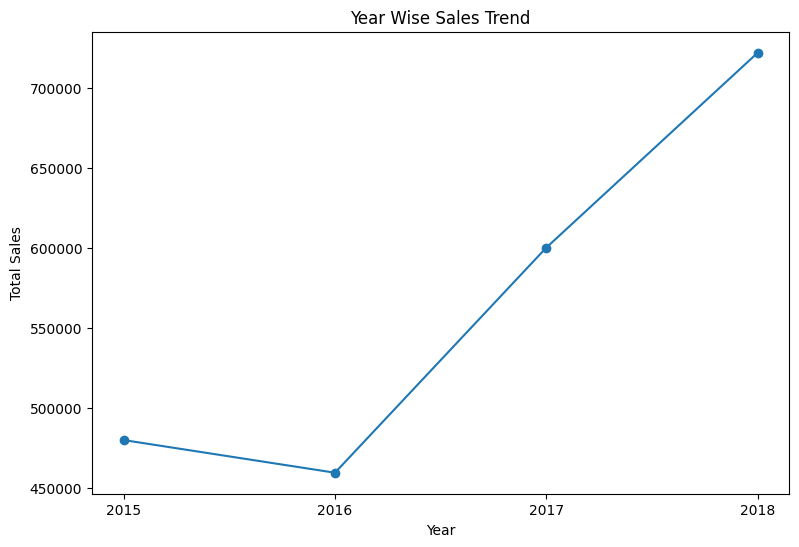

In [53]:
# YoY - Year over Year Sales Line Graph

plt.figure(figsize = (9,6))

plt.plot(
    yr_sales.index,
    yr_sales.values,
    marker = 'o'
)

# Year
plt.xticks(yr_sales.index)

plt.title('Year Wise Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.show()

In [54]:
# YoY Growth %

yoy_growth = yr_sales.pct_change() * 100
print(yoy_growth)

Year
2015.0          NaN
2016.0    -4.255484
2017.0    30.636812
2018.0    20.303396
Name: Sales, dtype: float64


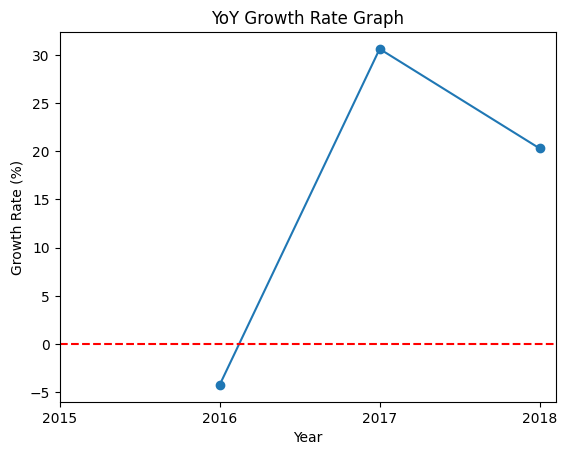

In [55]:
# YoY Growth Rate Graph

plt.Figure(figsize = (14,6))

plt.plot(
    yoy_growth.index,
    yoy_growth.values,
    marker = 'o'
)

# 0 Growth Line
plt.axhline(
    y = 0,
    color = 'red',
    linestyle = '--'
)

# Year
plt.xticks(yoy_growth.index)

plt.title('YoY Growth Rate Graph')
plt.xlabel('Year')
plt.ylabel('Growth Rate (%)')

plt.show()

In [56]:
# Rolling Yearly Trend
rolling_sales = yr_sales.rolling(window = 2).mean()
print(rolling_sales)

Year
2015.0             NaN
2016.0    469646.10675
2017.0    529814.27770
2018.0    661122.28460
Name: Sales, dtype: float64


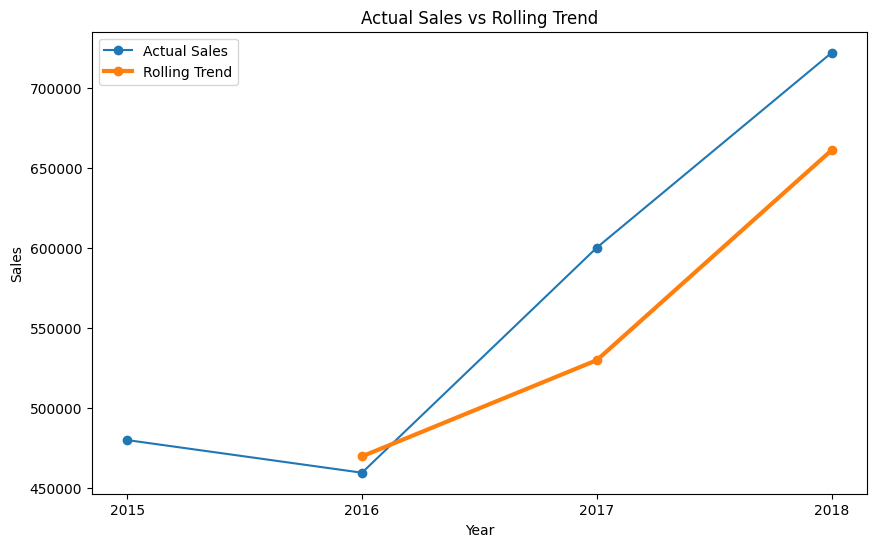

In [57]:
# Actual Yearly Sales vs Rolling Trend

plt.figure(figsize=(10,6))

# Actual yearly sales
plt.plot(
    yr_sales.index,
    yr_sales.values,
    marker='o',
    label='Actual Sales'
)

# Rolling trend
plt.plot(
    rolling_sales.index,
    rolling_sales.values,
    marker='o',
    linewidth=3,
    label='Rolling Trend'
)

plt.title('Actual Sales vs Rolling Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks(rolling_sales.index)

plt.legend()
plt.show()

In [58]:
# DAY 8 - 2ND JUNE

# Avg Sales Per Order 
order_sales = raw_df.groupby('Order ID')['Sales'].sum()
print("Average Sales per Order = ", order_sales.mean())

Average Sales per Order =  459.4751691791955


In [59]:
# Avg Sales Per Order by Segment
seg_order_sales = raw_df.groupby(
    ['Segment', 'Order ID']
)['Sales'].sum()

seg_aov = seg_order_sales.groupby('Segment').mean()
print(seg_aov)

Segment
Consumer       452.526816
Corporate      461.766650
Home Office    475.371563
Name: Sales, dtype: float64


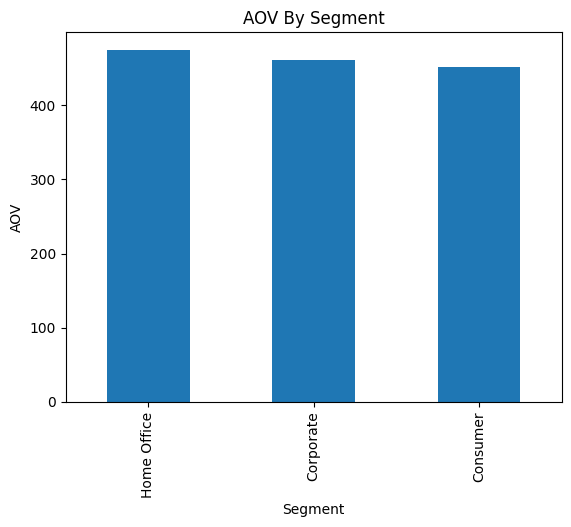

In [60]:
# Segment Wise Avg Order Val Bar Graph
plt.Figure(figsize = (14,6))
seg_aov.sort_values(ascending = False).plot(kind = 'bar')

plt.title('AOV By Segment')
plt.xlabel('Segment')
plt.ylabel('AOV')

plt.show()

In [61]:
# Order Frequency Analysis

# No. of Unique Orders by Segment 
seg_orders = raw_df.groupby('Segment')['Order ID'].nunique()
print(seg_orders)

Segment
Consumer       2537
Corporate      1491
Home Office     894
Name: Order ID, dtype: int64


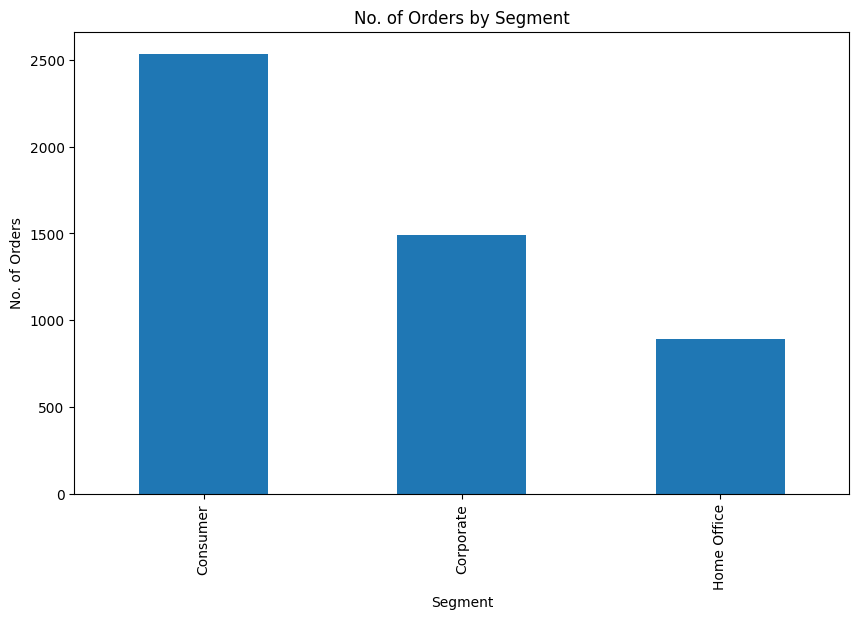

In [62]:
# Order Frequency By Segment Bar Graph
plt.figure(figsize = (10,6))
seg_orders.sort_values(ascending = False).plot(kind = 'bar')

plt.title('No. of Orders by Segment')
plt.xlabel('Segment')
plt.ylabel('No. of Orders')

plt.show()

In [63]:
# Repeat Customer Analysis

# No. of Orders per Customer
cust_orders = raw_df.groupby('Customer Name')['Order ID'].nunique()

# Summary Stats
print(cust_orders.describe())

count    793.000000
mean       6.206810
std        2.525647
min        1.000000
25%        4.000000
50%        6.000000
75%        8.000000
max       17.000000
Name: Order ID, dtype: float64


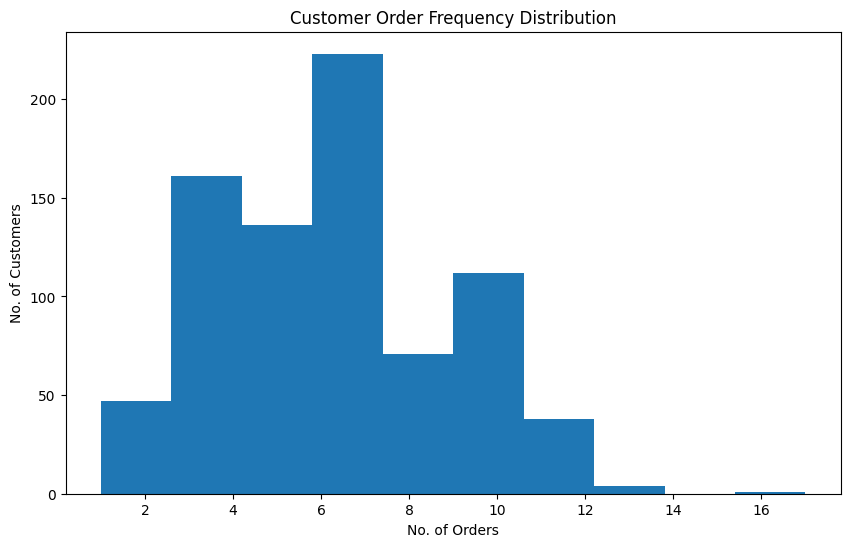

In [64]:
# Customer Order Frequency Distribution Histogram

plt.figure(figsize=(10,6))

plt.hist(
    cust_orders,
    bins = 10
)

plt.title('Customer Order Frequency Distribution')
plt.xlabel('No. of Orders')
plt.ylabel('No. of Customers')

plt.show()

In [65]:
# Top 10 Customers by Sales

top_cust = raw_df.groupby(
    'Customer Name'
)['Sales'].sum().sort_values(
    ascending = False
)

print(top_cust.head(10))

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


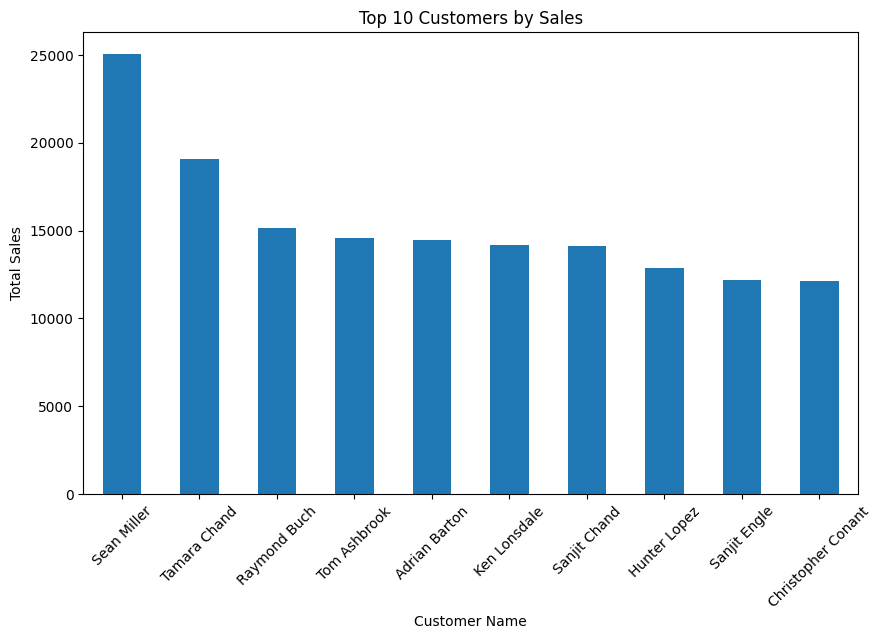

In [66]:
# Top 10 Customers by Sales Bar Graph

plt.figure(figsize=(10,6))
top_cust.head(10).plot(kind='bar')

plt.title('Top 10 Customers by Sales')
plt.xlabel('Customer Name')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.show()

In [67]:
# DAY 9 - 3RD JUNE

# TOP 10 PRODUCTS BY SALE
top_prod_sales = raw_df.groupby(
    'Product Name'
)['Sales'].sum().sort_values(
    ascending = False
)

print(top_prod_sales.head(10))

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


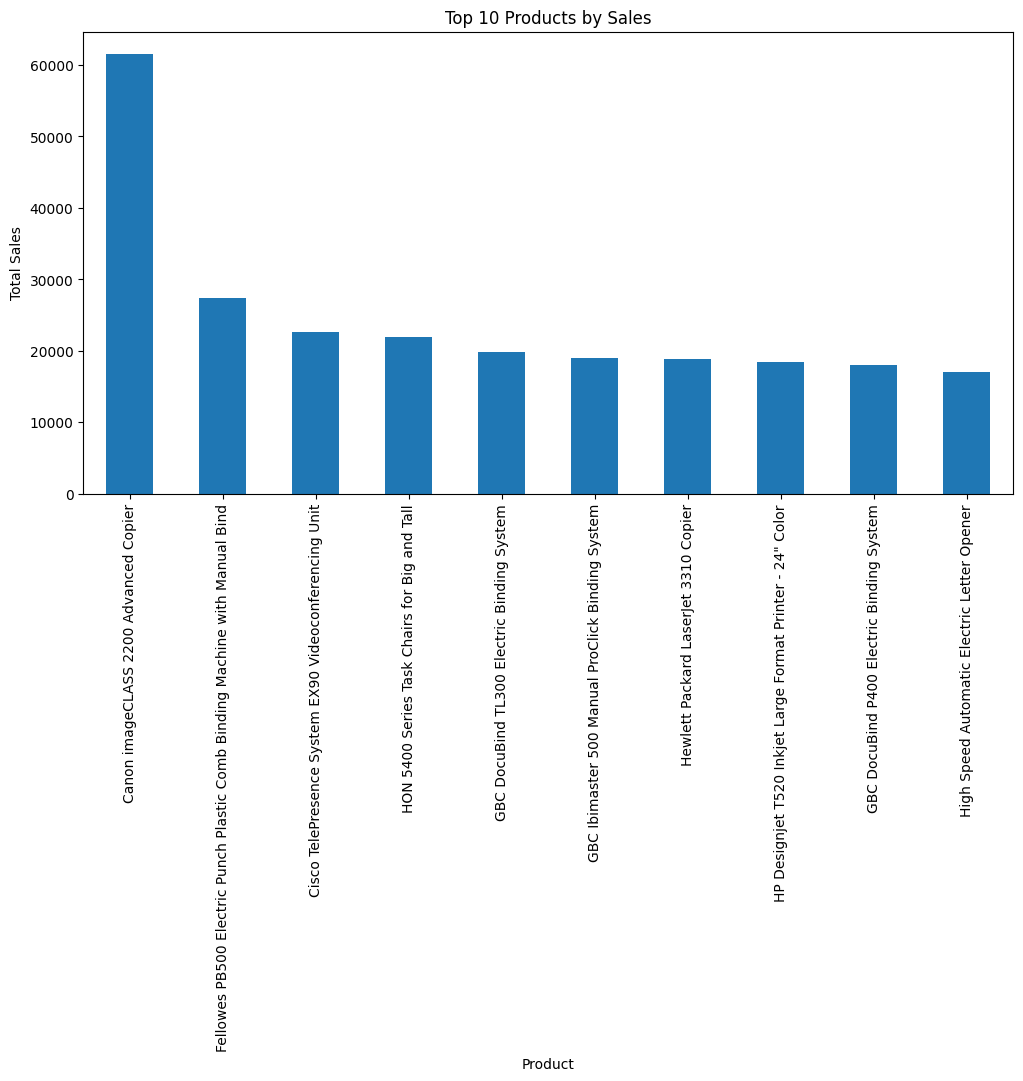

In [68]:
# TOP 10 PRODUCTS BY SALE BAR GRAPH

plt.figure(figsize = (12,6))
top_prod_sales.head(10).plot(kind = 'bar')

plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.xticks(rotation =  90)
plt.show()

In [69]:
# Remove rows where Category is '*'
raw_df = raw_df[raw_df['Category'] != '*']

# Check categories again
print(raw_df['Category'].unique())

<StringArray>
['Furniture', 'Office Supplies', 'Technology', nan]
Length: 4, dtype: str


In [70]:
# Remove missing category values
raw_df = raw_df.dropna(subset=['Category'])

# Check categories again
print(raw_df['Category'].unique())

<StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str


In [71]:
# PRODUCT CATEGORY DEPENDENCY

# CATEGORY CONTRI %
category_per = (
    raw_df.groupby('Category')['Sales'].sum()
    /
    raw_df['Sales'].sum()
) * 100

print(category_per)

Category
Furniture          32.219621
Office Supplies    31.192167
Technology         36.588212
Name: Sales, dtype: float64


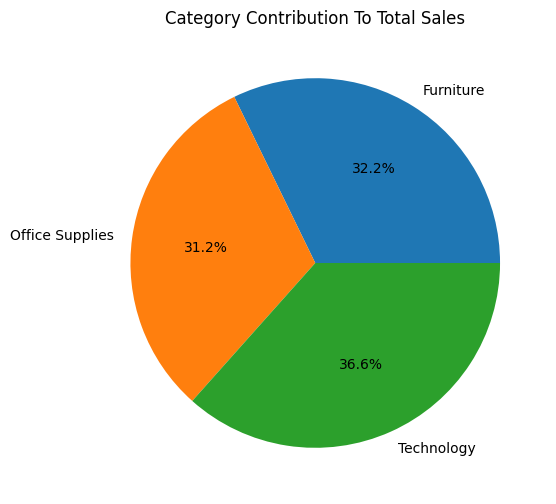

In [72]:
# CATEGORY CONTRIBUTION PIE CHART
plt.figure(figsize = (6,6))

category_per.plot(
    kind = 'pie',
    autopct = '%1.1f%%'
)

plt.ylabel('')

plt.title('Category Contribution To Total Sales')
plt.show()

In [73]:
# PRODUCT REVENUE DISTRIBUTION ANALYSIS

## PRODUCT SALES DISTRIBUTION SUMMARY

prod_sales = raw_df.groupby(
    'Product Name'
)['Sales'].sum()

print(prod_sales.describe())

count     1849.000000
mean      1223.113457
std       2774.252974
min          1.624000
25%         96.646000
50%        299.970000
75%       1184.032000
max      61599.824000
Name: Sales, dtype: float64


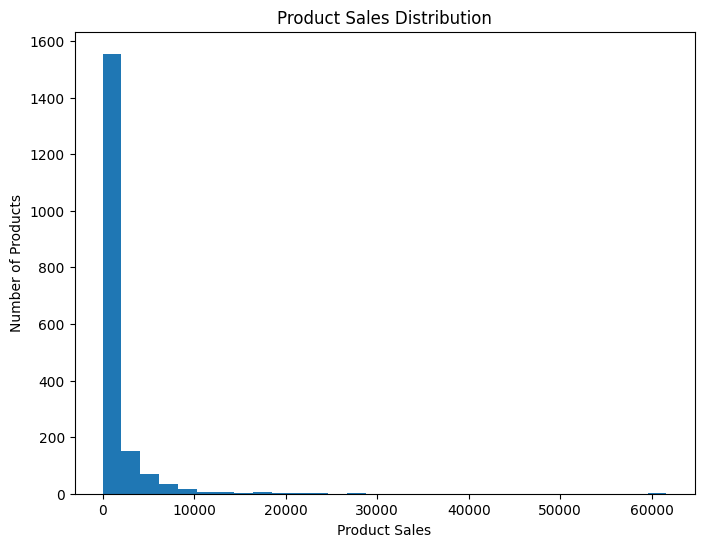

In [74]:
# Product sales distribution histogram

plt.figure(figsize=(8,6))

plt.hist(
    prod_sales,
    bins=30
)

plt.title('Product Sales Distribution')
plt.xlabel('Product Sales')
plt.ylabel('Number of Products')

plt.show()

In [75]:
# DAY 10 - 4th JUNE

# Monthly Sales Volatility
monthly_std = monthly_sales.std()
print("Monthly Sales Volatility =", monthly_std)

Monthly Sales Volatility = 90742.20539427323


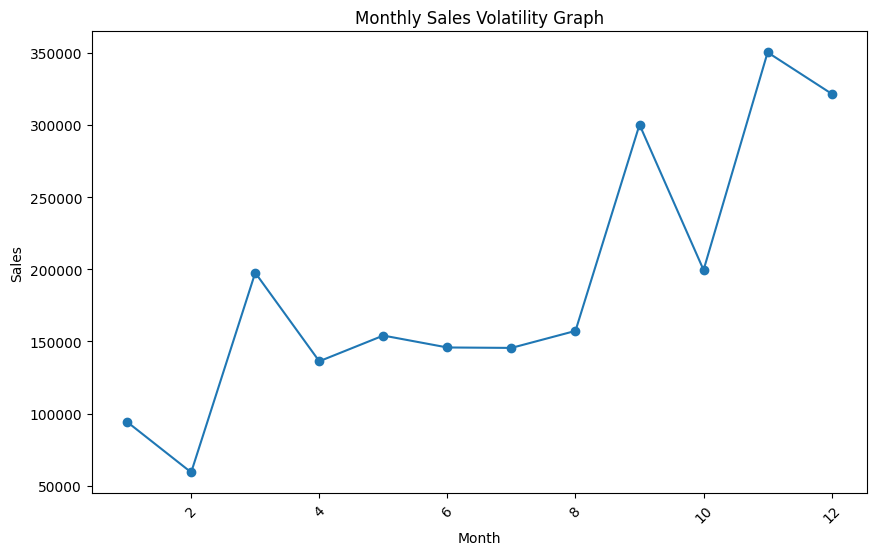

In [76]:
# Monthly Sales Volatility Graph
plt.figure(figsize = (10,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker = 'o'
)

plt.title('Monthly Sales Volatility Graph')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation = 45)
plt.show()

In [77]:
# Rolling Volatility
rolling_volatility = monthly_sales.rolling(
    window = 3
).std()

print(rolling_volatility.head())

Month
1.0             NaN
2.0             NaN
3.0    71863.908755
4.0    69248.221761
5.0    31529.393321
Name: Sales, dtype: float64


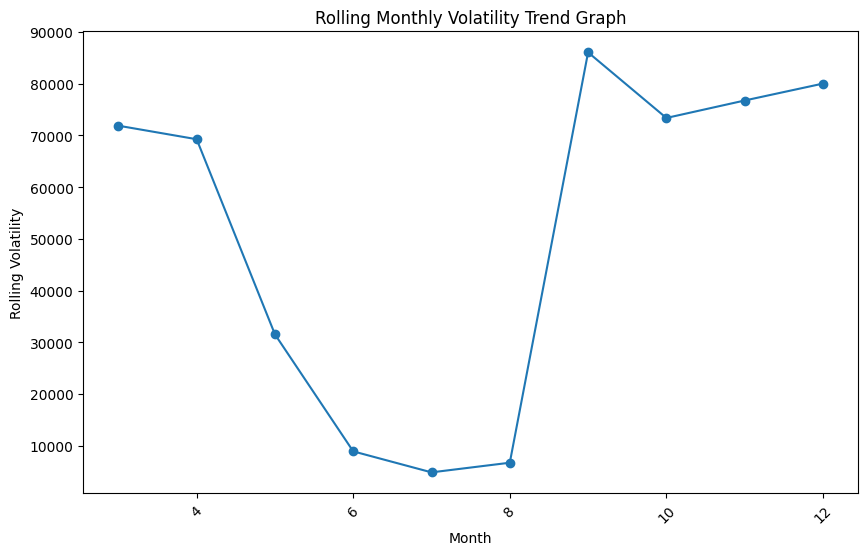

In [78]:
# Rolling Volatility Trend Graph
plt.figure(figsize = (10,6))

plt.plot(
    rolling_volatility.index,
    rolling_volatility.values,
    marker = 'o'
)

plt.title('Rolling Monthly Volatility Trend Graph')
plt.xlabel('Month')
plt.ylabel('Rolling Volatility')

plt.xticks(rotation = 45)
plt.show()

In [79]:
print(raw_df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Qtr', 'Year'],
      dtype='str')


In [80]:
# Convert Order Date properly

raw_df['Order Date'] = pd.to_datetime(
    raw_df['Order Date'],
    format='%d-%m-%Y'
)

# Recreate Month column

raw_df['Month'] = raw_df['Order Date'].dt.month

In [81]:
# Convert Order Date to datetime

raw_df['Order Date'] = pd.to_datetime(
    raw_df['Order Date']
)

# Recreate Month column

raw_df['Month'] = raw_df['Order Date'].dt.month

In [82]:
# Recreate monthly sales

monthly_sales = raw_df.groupby(
    'Month'
)['Sales'].sum()

# Recreate moving average

moving_avg = monthly_sales.rolling(
    window=3
).mean()

In [83]:
# Forecast Error Calculation
forecast_error = monthly_sales - moving_avg
print(forecast_error.head())

Month
1             NaN
2             NaN
3    80494.809800
4     5207.099533
5    -8561.046800
Name: Sales, dtype: float64


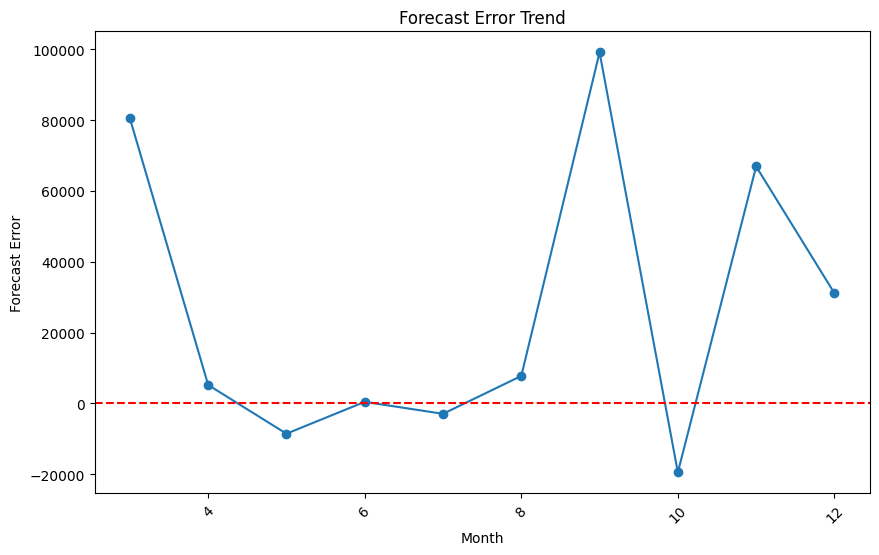

In [84]:
# Forecast Error Trend Graph

plt.figure(figsize=(10,6))

plt.plot(
    forecast_error.index,
    forecast_error.values,
    marker='o'
)

# Zero-error reference line
plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.title('Forecast Error Trend')
plt.xlabel('Month')
plt.ylabel('Forecast Error')

plt.xticks(rotation=45)

plt.show()

In [85]:
# Mean Absolute Error - MAE for Forecast Error
mae_forecast = forecast_error.abs().mean()
print("MAE =", mae_forecast)

MAE = 32200.45690000001


In [86]:
# Mean Absolute Percentage Error
mape = (
    (forecast_error.abs() / monthly_sales)
    .mean()
) * 100

print("MAPE =", mape)

MAPE = 12.894512423444079


In [87]:
# DAY 11 - 5TH JUNE

# MONTHLY GROWTH %
monthly_growth = monthly_sales.pct_change()*100
print(monthly_growth)

Month
1            NaN
2     -37.034586
3     232.777287
4     -31.021650
5      13.063789
6      -5.353609
7      -0.206966
8       8.094398
9      90.764799
10    -33.524150
11     75.522915
12     -8.190942
Name: Sales, dtype: float64


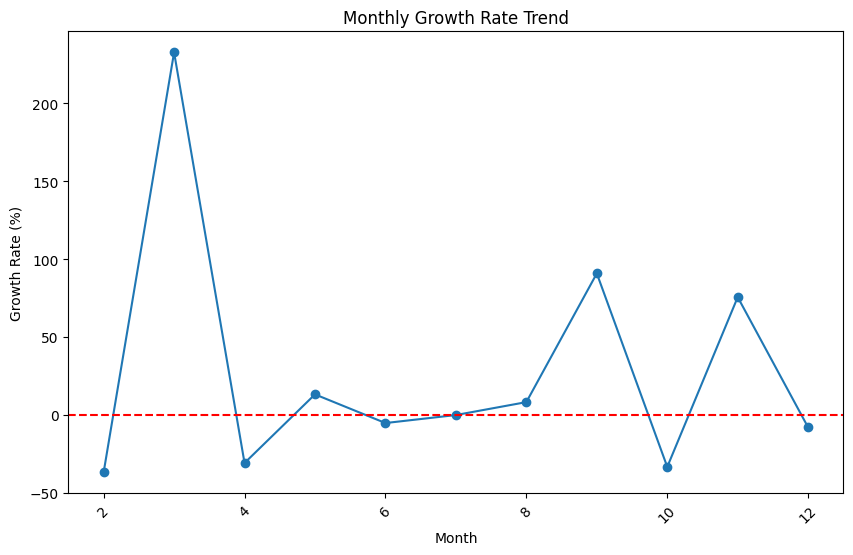

In [88]:
# MONTHLY GROWTH RATE TREND GRAPH

plt.figure(figsize = (10,6))

plt.plot(
    monthly_growth.index,
    monthly_growth.values,
    marker = 'o'
)

# 0 Growth Ref Line
plt.axhline(
    y = 0,
    color = 'red',
    linestyle = '--'
)

plt.title('Monthly Growth Rate Trend')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')

plt.xticks(rotation = 45)
plt.show()

In [89]:
# GROWTH vs VOLATILITY RELATIONSHIP ANALYSIS

growth_volatility_df = pd.DataFrame({
    'Growth': monthly_growth,
    'Volatility' : rolling_volatility
})

print(growth_volatility_df)

           Growth    Volatility
Month                          
1             NaN           NaN
2      -37.034586           NaN
3      232.777287  71863.908755
4      -31.021650  69248.221761
5       13.063789  31529.393321
6       -5.353609   8909.833215
7       -0.206966   4852.157692
8        8.094398   6715.887417
9       90.764799  86040.901800
10     -33.524150  73358.981724
11      75.522915  76732.970954
12      -8.190942  80002.879326


In [90]:
# COEFFICIENT OF VARIATION (CV) ANALYSIS

# CV = STD DEVIATION / MEAN

# CALCULATION OF CV

cv = (
    monthly_sales.std()
    /
    monthly_sales.mean()
)

print("Coefficient of Variation (CV) =", cv)

Coefficient of Variation (CV) = 0.48148961054317096


In [91]:
# DAY 12 - 6TH JUNE

# CORRELATION BETWEEN GROWTH & VOLATILITY
corr = growth_volatility_df[
    ['Growth', 'Volatility']
].corr()

print(corr)

              Growth  Volatility
Growth      1.000000    0.328913
Volatility  0.328913    1.000000


In [92]:
# TRAIN TEST SPLIT FOR FORECASTING

# TIME INDEX 
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df.columns = ['Month', 'Sales']

# FEATURES & TARGET
X = monthly_sales_df[['Month']]
y = monthly_sales_df['Sales']

In [93]:
# DATA SPLITTING
from sklearn.model_selection import train_test_split

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    shuffle = False
)

print("Training Data Size =", len(X_train))
print("Testing Data Size =", len(X_test))

Training Data Size = 9
Testing Data Size = 3


In [94]:
# LINEAR REGRESSION MODEL CREATING & TRAINING
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
# SALES PREDICTION ON TEST DATA
y_pred = model.predict(X_test)
print(y_pred)

[239702.091625   256744.76311667 273787.43460833]


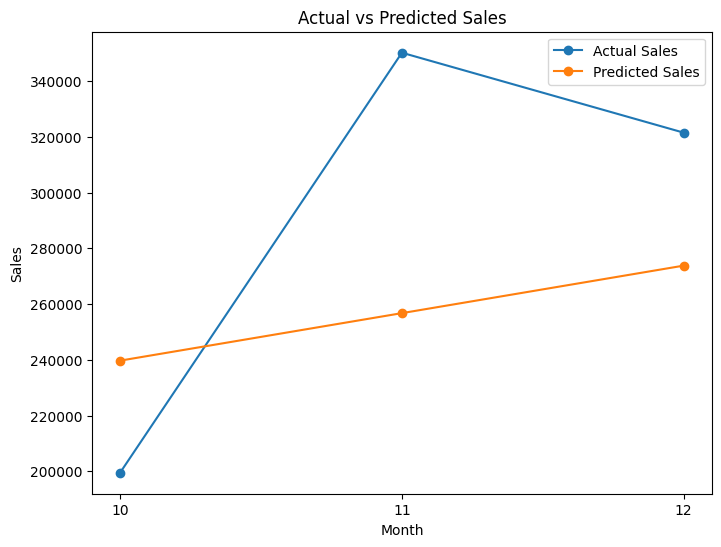

In [96]:
# Actual vs Predicted Sales

plt.figure(figsize=(8,6))

# Actual values
plt.plot(
    X_test,
    y_test,
    marker='o',
    label='Actual Sales'
)

# Predicted values
plt.plot(
    X_test,
    y_pred,
    marker='o',
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Sales')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.legend()

# Clean month labels
plt.xticks(X_test.values.flatten())

plt.show()

In [97]:
# UPDATED R² SCORE
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R² Score =", r2)

R² Score = 0.014303047067471097


In [98]:
# Future months (updated)

future_months = pd.DataFrame({
    'Month': [13, 14, 15]
})

# Predict future sales

future_predictions = model.predict(
    future_months
)

print(future_predictions)

[290830.1061     307872.77759167 324915.44908333]


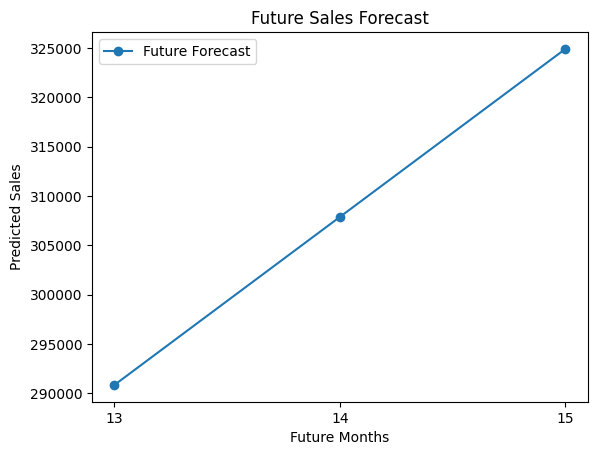

In [99]:
# DAY 13 - 8TH JUNE

# FUTURE FORECAST GRAPH
plt.Figure(figsize =(10,6))

# FUTURE FORECAST LINE
plt.plot(
    future_months['Month'],
    future_predictions,
    marker = 'o',
    label = 'Future Forecast'
    )

plt.title('Future Sales Forecast')
plt.xlabel('Future Months')
plt.ylabel('Predicted Sales')

plt.legend()

plt.xticks(future_months['Month'])
plt.show()

In [100]:
# DAY 15 - 10TH JUNE 

# DATSET SS FOR PPT

raw_df[['Order Date', 'Category', 'Region', 'Segment' ,'Sales']].head()

,Order Date,Category,Region,Segment,Sales
0,2017-11-08,Furniture,South,Consumer,261.9600
1,2017-11-08,Furniture,South,Consumer,731.9400
2,2017-06-12,Office Supplies,West,Corporate,14.6200
3,2016-10-11,Furniture,South,Consumer,957.5775
4,2016-10-11,Office Supplies,South,Consumer,22.3680


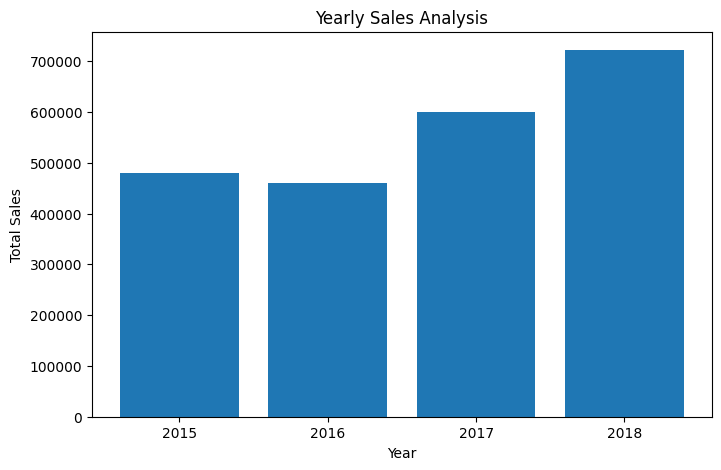

In [101]:
# yearly sales ppt updated

yr_sales = raw_df.groupby('Year')['Sales'].sum()

yr_sales.index = yr_sales.index.astype(int)

plt.figure(figsize=(8,5))
plt.bar(yr_sales.index, yr_sales.values)

plt.title('Yearly Sales Analysis')
plt.xlabel('Year')
plt.ylabel('Total Sales')

plt.xticks(yr_sales.index)

plt.show()

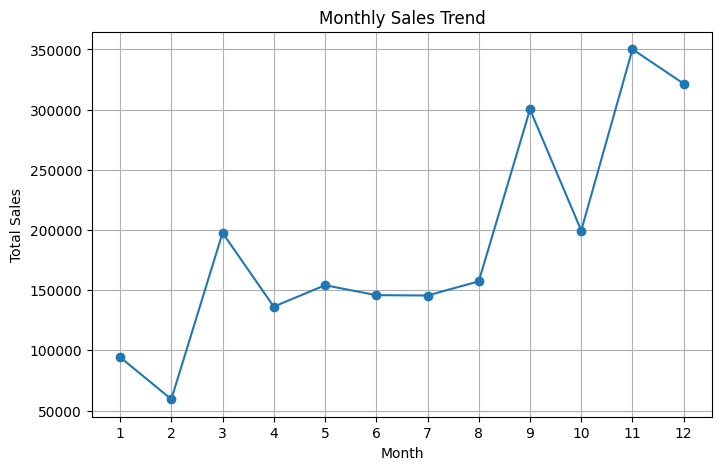

In [102]:
# ppt updated monthly graph

monthly_sales = raw_df.groupby('Month')['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(int)

plt.figure(figsize=(8,5))

plt.plot(monthly_sales.index,
         monthly_sales.values,
         marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(monthly_sales.index)

plt.grid(True)

plt.show()

In [103]:
raw_df['Order Date'] = pd.to_datetime(raw_df['Order Date'])

raw_df['Quarter'] = raw_df['Order Date'].dt.quarter

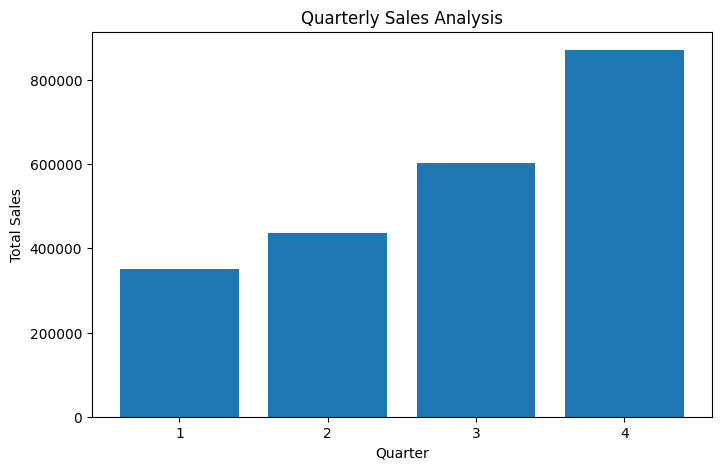

In [104]:
# Quarterly PPT Graph

qtr_sales = raw_df.groupby('Quarter')['Sales'].sum()

qtr_sales.index = qtr_sales.index.astype(int)
plt.figure(figsize=(8,5))
plt.bar(qtr_sales.index, qtr_sales.values)

plt.title('Quarterly Sales Analysis')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.xticks(qtr_sales.index)

plt.show()

c:\Users\eduwo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


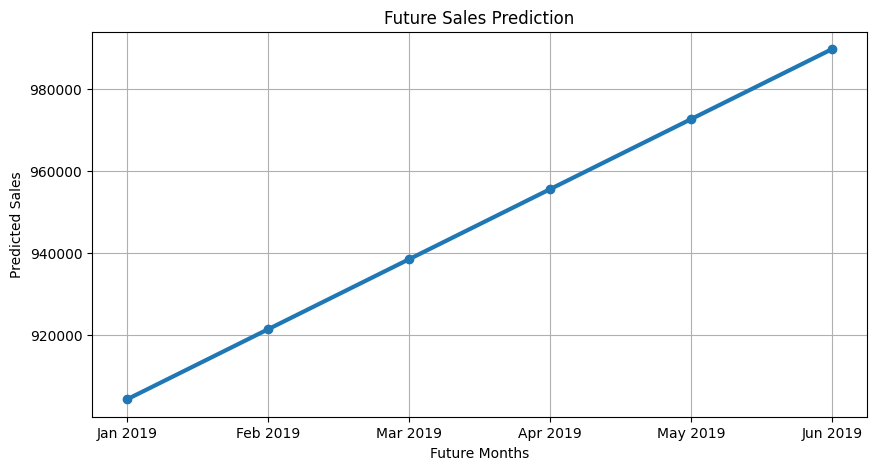

In [106]:
# Future Sales Prediction Graph

import numpy as np
future_time = np.array([[49], [50], [51], [52], [53], [54]])

future_prediction = model.predict(future_time)

future_labels = [
    'Jan 2019',
    'Feb 2019',
    'Mar 2019',
    'Apr 2019',
    'May 2019',
    'Jun 2019'
]

plt.figure(figsize=(10,5))

plt.plot(future_labels,
         future_prediction,
         marker='o',
         linewidth=3)

plt.title("Future Sales Prediction")
plt.xlabel("Future Months")
plt.ylabel("Predicted Sales")

plt.grid(True)

plt.show()